# CardioIA — Fase 2 · Análise de vieses

> ⚠️ **AVISO CLÍNICO:** Este sistema é um protótipo acadêmico e **NÃO** substitui avaliação médica.  
> Supervisionado por Dra. Fernanda Fassina (CRM-SP 169944).

**Pergunta:** onde o extrator por regras (Parte 1) e o classificador TF-IDF (Parte 2) erram de forma **sistemática**, e o que dados reais brasileiros dizem sobre isso?

| Seção | O que mede |
|---|---|
| 1 | Casos de comportamento: negação, gênero, acento, linguagem coloquial, apresentação atípica |
| 2–3 | Contrafactuais: trocar o gênero de quem relata e tirar acentos muda o resultado? |
| 4 | Negação: o ponto cego do "saco de palavras" |
| 5 | Pistas espúrias herdadas dos templates |
| 6 | Quanto vale a variedade dos dados (ablação) |
| 7 | Regras + ML como redes de segurança complementares |
| 8 | Recall por tipo de alarme |
| 9 | **PNS 2013 (Fase 1):** "dor no peito" é um sinal igualmente bom para homens e mulheres? |
| 10 | Resumo dos vieses e mitigações |

> As seções 6 e 7 usam o teste de forma **exploratória**, depois da avaliação oficial (notebook 02). Elas **não** mudam o modelo oficial; servem para planejar a próxima rodada, que precisa de um teste novo.


In [1]:
import json
import sys
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold


def achar_pasta_fase2():
    """Localiza fase2/ a partir de onde o notebook está sendo executado."""
    for pasta in [Path.cwd(), *Path.cwd().parents]:
        for candidata in (pasta, pasta / "fase2"):
            if (candidata / "src" / "extrator_sintomas.py").exists():
                return candidata
    raise FileNotFoundError("pasta fase2/ não encontrada")


FASE2 = achar_pasta_fase2()
RAIZ = FASE2.parent
sys.path.insert(0, str(FASE2 / "src"))

from analisador_clinico import analisar_relato
from avaliacao import NEGATIVO, POSITIVO, SEED, calcular_metricas, criar_modelos
from carregador_base import carregar_base_conhecimento, carregar_relatos
from classificador_regras import classificar_por_regras
from contrato_dataset import carregar_dataset_risco
from vieses import tem_marca_de_genero, trocar_genero

pd.set_option("display.max_colwidth", 100)
base = carregar_base_conhecimento()
df = carregar_dataset_risco()
treino = df[df["particao"] == "treino"]
teste = df[df["particao"] == "teste"]

relatorio = json.loads((FASE2 / "reports" / "metricas_todos.json").read_text(encoding="utf-8"))
NOME_MODELO = relatorio["modelo_escolhido"]
modelo = criar_modelos()[NOME_MODELO].fit(treino["frase"], treino["situacao"])
print("Modelo oficial (escolhido por validação cruzada no notebook 02):", NOME_MODELO)


def prob_alto(frases, m=modelo):
    return m.predict_proba(list(frases))[:, list(m.classes_).index(POSITIVO)]


def rotulo(probabilidades):
    return np.where(np.asarray(probabilidades) >= 0.5, POSITIVO, NEGATIVO)


def regras(frases):
    return [classificar_por_regras(f, base)[0] for f in frases]

Modelo oficial (escolhido por validação cruzada no notebook 02): naive_bayes


## 1. Casos de comportamento

São 15 frases em `data/casos_comportamento.csv`, escritas para expor falhas típicas. Elas são **relatadas, não usadas como meta**, para não serem "decoradas".

In [2]:
casos = pd.read_csv(FASE2 / "data" / "casos_comportamento.csv", encoding="utf-8-sig", dtype=str)
casos["prob_alto (ML)"] = prob_alto(casos["frase"]).round(2)
casos["ML"] = rotulo(casos["prob_alto (ML)"])
casos["regras"] = regras(casos["frase"])
casos[["caso_id", "tipo", "frase", "risco_esperado", "ML", "prob_alto (ML)", "regras"]]

,caso_id,tipo,frase,risco_esperado,ML,prob_alto (ML),regras
0,CB01,negacao,"Não sinto dor no peito, só um cansaço leve no fim do dia.",baixo risco,baixo risco,0.03,baixo risco
1,CB02,negacao,Não tenho falta de ar e consigo caminhar normalmente.,baixo risco,baixo risco,0.28,baixo risco
2,CB03,negacao,"Nunca desmaiei, só fico um pouco tonto quando levanto rápido da cama.",baixo risco,baixo risco,0.12,baixo risco
3,CB04,genero,Estou muito cansado e com falta de ar mesmo parado desde hoje cedo.,alto risco,alto risco,0.77,baixo risco
4,CB05,genero,Estou muito cansada e com falta de ar mesmo parada desde hoje cedo.,alto risco,alto risco,0.75,baixo risco
5,CB06,genero,Fiquei tonto e senti um aperto no peito que não passa.,alto risco,alto risco,0.90,alto risco
6,CB07,genero,Fiquei tonta e senti um aperto no peito que não passa.,alto risco,alto risco,0.92,alto risco
7,CB08,acento,Estou com uma pressão no peito há mais de vinte minutos.,alto risco,alto risco,0.78,alto risco
8,CB09,acento,Estou com uma pressao no peito ha mais de vinte minutos.,alto risco,alto risco,0.78,alto risco
9,CB10,coloquial,Tô com uma agonia no peito que não passa de jeito nenhum.,alto risco,alto risco,0.84,baixo risco


In [3]:
(
    casos.assign(ML=casos["ML"] == casos["risco_esperado"], regras=casos["regras"] == casos["risco_esperado"])
    .groupby("tipo")[["ML", "regras"]].agg(["sum", "count"])
)

ML       regras      
          sum count    sum count
tipo                            
acento      2     2      2     2
atipico     3     3      1     3
coloquial   3     3      1     3
genero      4     4      2     4
negacao     3     3      3     3

**Leitura.**

- O **ML acerta os 15 casos**, mas "Me deu um troço no coração e apaguei" passa raspando (P = 0,52).
- As **regras erram 6 de 15**, e todos os erros são de **vocabulário**, não de raciocínio:
  - "mesmo parado" (a base só tem "mesmo **estando** parado");
  - "agonia no peito", "apaguei", "suando frio" e "sem forças" não estão na base.

É o viés do **vocabulário de livro**: o sistema por regras só entende quem fala como a diretriz.

## 2. Contrafactual de gênero

Trocamos o gênero gramatical de quem relata ("fiquei tont**o**" ↔ "fiquei tont**a**") e conferimos se o resultado muda.

**No extrator (Parte 1)**, a análise dos 10 relatos precisa ser idêntica. Isso é garantido por teste (`test_relato_escrito_por_mulher_tem_a_mesma_analise`) e por um **contrato da base**: toda expressão flexionada precisa existir nos dois gêneros. Esse contrato encontrou lacunas reais em **2 expressões e 4 atributos**, que foram corrigidas. Exemplos:

- "estava sentad**a**";
- "mesmo estando parad**a**";
- "me deixando mais cansad**a**";
- "respiração piora deitad**a**".

Antes da correção, a versão feminina do RELATO 07 perdia o contexto "em repouso" e a do RELATO 09 perdia o sintoma "cansaço".

In [4]:
linhas = []
for relato in carregar_relatos():
    trocado = trocar_genero(relato["texto"])
    original, contrafactual = analisar_relato(relato["texto"], base), analisar_relato(trocado, base)
    linhas.append({
        "relato": relato["id"],
        "tem marca de gênero": trocado != relato["texto"],
        "sugestão (original)": original["sugestao"]["condicao"],
        "sugestão (gênero trocado)": contrafactual["sugestao"]["condicao"],
        "mesma análise": (
            {c["conceito_id"] for c in original["conceitos"]} == {c["conceito_id"] for c in contrafactual["conceitos"]}
            and {a["atributo_id"] for a in original["atributos"]} == {a["atributo_id"] for a in contrafactual["atributos"]}
            and original["sugestao"] == contrafactual["sugestao"]
        ),
    })
pd.DataFrame(linhas)

,relato,tem marca de gênero,sugestão (original),sugestão (gênero trocado),mesma análise
0,RELATO 01,True,Insuficiência Cardíaca,Insuficiência Cardíaca,True
1,RELATO 02,True,Insuficiência Cardíaca,Insuficiência Cardíaca,True
2,RELATO 03,True,Insuficiência Cardíaca,Insuficiência Cardíaca,True
3,RELATO 04,True,IAM / Síndrome Coronariana Aguda,IAM / Síndrome Coronariana Aguda,True
4,RELATO 05,True,IAM / Síndrome Coronariana Aguda,IAM / Síndrome Coronariana Aguda,True
5,RELATO 06,False,Angina / Doença Coronariana,Angina / Doença Coronariana,True
6,RELATO 07,True,IAM / Síndrome Coronariana Aguda,IAM / Síndrome Coronariana Aguda,True
7,RELATO 08,False,Insuficiência Cardíaca,Insuficiência Cardíaca,True
8,RELATO 09,True,Insuficiência Cardíaca,Insuficiência Cardíaca,True
9,RELATO 10,False,Insuficiência Cardíaca,Insuficiência Cardíaca,True


**No classificador (Parte 2):** frases do teste e dos casos de comportamento que têm marca de gênero.

In [5]:
com_genero = [f for f in list(teste["frase"]) + list(casos["frase"]) if tem_marca_de_genero(f)]
trocadas = [trocar_genero(f) for f in com_genero]
p_original, p_trocada = prob_alto(com_genero), prob_alto(trocadas)

print(f"Frases com marca de gênero: {len(com_genero)}")
print(f"Classificação do ML mudou em: {(rotulo(p_original) != rotulo(p_trocada)).sum()}")
print(f"Maior variação de P(alto) no ML: {np.abs(p_original - p_trocada).max():.3f}")
print(f"Classificação das regras mudou em: {sum(a != b for a, b in zip(regras(com_genero), regras(trocadas)))}")

Frases com marca de gênero: 20
Classificação do ML mudou em: 0
Maior variação de P(alto) no ML: 0.035
Classificação das regras mudou em: 0


**Leitura:** nenhuma frase mudou de classe, e a probabilidade variou no máximo 0,035. O dataset foi escrito com vozes feminina (17) e masculina (18) equilibradas. Isso **não prova** ausência de viés de gênero: a seção 9 mostra um viés mais profundo, que não depende da gramática, e sim de **como os sintomas se apresentam**.

## 3. Acentos

Tanto o TF-IDF quanto o extrator usam a mesma normalização, que remove os acentos. Por construção, tirar os acentos não pode mudar nada:

In [6]:
def sem_acento(texto):
    return "".join(c for c in unicodedata.normalize("NFD", texto) if unicodedata.category(c) != "Mn")


frases = list(teste["frase"])
print("Mudanças no ML:", (rotulo(prob_alto(frases)) != rotulo(prob_alto(map(sem_acento, frases)))).sum())
print("Mudanças nas regras:", sum(a != b for a, b in zip(regras(frases), regras(map(sem_acento, frases)))))

Mudanças no ML: 0


Mudanças nas regras: 0


## 4. Negação: o ponto cego do "saco de palavras"

O TF-IDF trata a frase como um conjunto de palavras, sem ordem. "Não sinto dor no peito" e "sinto dor no peito" diferem só em **uma** palavra. Comparamos pares afirmativo/negado:

In [7]:
pares = [
    ("Estou com dor no peito e falta de ar.", "Não estou com dor no peito nem falta de ar."),
    ("Sinto um aperto no peito que vai para o braço.", "Não sinto aperto no peito que vai para o braço."),
    ("Desmaiei hoje no trabalho.", "Não desmaiei hoje no trabalho."),
    ("Acordo de madrugada com falta de ar.", "Não acordo de madrugada com falta de ar."),
    ("Comecei a suar frio e sentir enjoo.", "Não comecei a suar frio nem senti enjoo."),
    ("Estou com falta de ar em repouso.", "Não estou com falta de ar em repouso."),
]
afirmadas, negadas = [a for a, _ in pares], [n for _, n in pares]
pd.DataFrame({
    "frase afirmativa": afirmadas,
    "P(alto) afirmativa": prob_alto(afirmadas).round(2),
    "P(alto) negada": prob_alto(negadas).round(2),
    "ML na negada": rotulo(prob_alto(negadas)),
    "regras na negada": regras(negadas),
})

,frase afirmativa,P(alto) afirmativa,P(alto) negada,ML na negada,regras na negada
0,Estou com dor no peito e falta de ar.,0.56,0.35,baixo risco,baixo risco
1,Sinto um aperto no peito que vai para o braço.,0.89,0.86,alto risco,baixo risco
2,Desmaiei hoje no trabalho.,0.81,0.72,alto risco,baixo risco
3,Acordo de madrugada com falta de ar.,0.82,0.80,alto risco,baixo risco
4,Comecei a suar frio e sentir enjoo.,0.95,0.92,alto risco,baixo risco
5,Estou com falta de ar em repouso.,0.79,0.77,alto risco,baixo risco


**Leitura:** para o ML, negar o sintoma quase não muda nada. "Não sinto aperto no peito que vai para o braço" ainda sai com P(alto) = 0,86, e só o primeiro par muda de classe. As **regras acertam todos os pares**, porque o extrator da Parte 1 trata negação (NegEx simplificado).

E por que o ML acertou os casos de negação da seção 1? Dois dos três têm o molde dos templates de negação ("Não sinto dor no peito, **só** um cansaço leve…"). O ML acertou pelo **estilo**, não por entender a negação.

In [8]:
com_nao_e_alto = [
    "A dor no peito não passa e já vai para o braço.",
    "Não consigo respirar direito desde cedo, mesmo parado.",
    "O aperto no peito não melhora com repouso.",
    "Não aguento a dor no peito, começou de repente.",
]
pd.DataFrame({"frase (alto risco, com 'não')": com_nao_e_alto, "P(alto) ML": prob_alto(com_nao_e_alto).round(2),
              "ML": rotulo(prob_alto(com_nao_e_alto)), "regras": regras(com_nao_e_alto)})

,"frase (alto risco, com 'não')",P(alto) ML,ML,regras
0,A dor no peito não passa e já vai para o braço.,0.88,alto risco,alto risco
1,"Não consigo respirar direito desde cedo, mesmo parado.",0.79,alto risco,baixo risco
2,O aperto no peito não melhora com repouso.,0.65,alto risco,baixo risco
3,"Não aguento a dor no peito, começou de repente.",0.87,alto risco,alto risco


O contrário também vale: quando "não" aparece numa frase de alto risco ("não passa", "não melhora"), o ML acerta. Aqui as regras erram duas vezes, de novo por vocabulário: "não consigo respirar" e "não melhora com repouso" não estão na base.

## 5. Pistas espúrias herdadas dos templates

Os templates repetem moldes, como "Comecei a sentir…", "…, só…", "há dois dias" e "depois do almoço". O modelo aprende esses moldes como se fossem sinais clínicos. Teste direto: mudamos **só palavras sem sentido clínico**.

In [9]:
sondas = [
    ("Estou com dor de cabeça leve.", "Comecei a sentir dor de cabeça leve agora."),
    ("Desmaiei no trabalho.", "Desmaiei no trabalho hoje de manhã."),
    ("Sinto azia.", "Sinto azia depois do almoço."),
    ("Estou com suor frio e enjoo.", "Estou com suor frio e enjoo, só isso."),
]
antes, depois = [a for a, _ in sondas], [d for _, d in sondas]
pd.DataFrame({"frase": antes, "P(alto)": prob_alto(antes).round(2), "com palavra não clínica": depois,
              "P(alto) depois": prob_alto(depois).round(2), "mudou de classe": rotulo(prob_alto(antes)) != rotulo(prob_alto(depois))})

,frase,P(alto),com palavra não clínica,P(alto) depois,mudou de classe
0,Estou com dor de cabeça leve.,0.13,Comecei a sentir dor de cabeça leve agora.,0.52,True
1,Desmaiei no trabalho.,0.76,Desmaiei no trabalho hoje de manhã.,0.55,False
2,Sinto azia.,0.18,Sinto azia depois do almoço.,0.36,False
3,Estou com suor frio e enjoo.,0.94,"Estou com suor frio e enjoo, só isso.",0.90,False


In [10]:
def contar(termo, dados):
    """Em quantas frases o termo aparece, por classe e origem."""
    from extrator_sintomas import normalizar_texto
    presente = (" " + dados["frase"].map(normalizar_texto) + " ").str.contains(f" {termo} ", regex=False)
    return dados[presente].groupby(["situacao", "origem"]).size()


pd.DataFrame({termo: contar(termo, treino) for termo in ["comecei", "agora", "so", "hoje de manha", "depois do almoco", "ha dois dias"]}).fillna(0).astype(int).T

situacao         alto risco          baixo risco         
origem               manual template      manual template
comecei                   2       12           0        0
agora                     2       12           0        0
so                        3        0           6       20
hoje de manha             0        0           0        3
depois do almoco          0        4           0        0
ha dois dias              0        0           0       13

**Leitura:** basta trocar "Estou com" por "**Comecei a sentir** … **agora**" para uma dor de cabeça leve ir de P(alto) = 0,13 para 0,52, e **mudar de classe**. Pelas contagens, "comecei" e "agora" aparecem quase só em frases de alto risco do treino, e "só" e "há dois dias" quase só em frases de baixo risco, em geral nos templates. É um viés **criado por nós** ao gerar os dados.

**Mitigação para a próxima rodada:** variar as aberturas dos templates entre as duas classes e aumentar a proporção de frases manuais.

## 6. Quanto vale a variedade dos dados? *(exploratório)*

Treinamos o mesmo tipo de modelo com cada parte do treino e medimos no teste. É **exploratório**: o modelo oficial não muda.

In [11]:
conjuntos = {
    "só templates (180)": treino[treino["origem"] == "template"],
    "só manuais (80)": treino[treino["origem"] == "manual"],
    "manuais + templates (260)": treino,
}
linhas = []
for nome, dados in conjuntos.items():
    for tipo_modelo in (NOME_MODELO, "logreg"):
        m = criar_modelos()[tipo_modelo].fit(dados["frase"], dados["situacao"])
        metricas = calcular_metricas(teste["situacao"].tolist(), m.predict(teste["frase"]).tolist())
        linhas.append({"treino": nome, "modelo": tipo_modelo, "acurácia": metricas["acuracia"],
                       "recall alto risco": metricas["recall_alto_risco"], "precisão alto risco": metricas["precisao_alto_risco"]})
pd.DataFrame(linhas).round(3)

,treino,modelo,acurácia,recall alto risco,precisão alto risco
0,só templates (180),naive_bayes,0.867,0.867,0.867
1,só templates (180),logreg,0.883,0.900,0.871
2,só manuais (80),naive_bayes,0.900,0.900,0.900
3,só manuais (80),logreg,0.900,0.867,0.929
4,manuais + templates (260),naive_bayes,0.917,0.900,0.931
5,manuais + templates (260),logreg,0.933,0.967,0.906


**Leitura:**

- **80 frases manuais rendem tanto quanto 180 templates.** No Naive Bayes, os templates sozinhos dão acurácia e recall de 0,867; as manuais sozinhas dão 0,900.
- Combinar as duas é o melhor dos três cenários.
- **Variedade vale mais que volume**: a próxima frase que vale a pena adicionar é uma frase real e diferente, não mais um template.

## 7. Regras + ML: redes de segurança complementares

As regras erram por **vocabulário**; o ML erra por **negação e estilo**. Os erros são diferentes, então uma combinação simples pode ajudar: **alto risco se o ML *ou* as regras disserem alto risco**. Avaliamos primeiro do jeito legítimo, com validação cruzada **só no treino**, e depois, de forma exploratória, no teste.

In [12]:
validacao = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
frases_treino, rotulos_treino = treino["frase"].to_numpy(), treino["situacao"].to_numpy()
resultados = {"ML": [], "regras": [], "ML ou regras": []}

for indices_treino, indices_validacao in validacao.split(frases_treino, rotulos_treino):
    m = criar_modelos()[NOME_MODELO].fit(frases_treino[indices_treino], rotulos_treino[indices_treino])
    ml = m.predict(frases_treino[indices_validacao])
    rg = np.array(regras(frases_treino[indices_validacao]))
    combinado = np.where((ml == POSITIVO) | (rg == POSITIVO), POSITIVO, NEGATIVO)
    for nome, previsto in (("ML", ml), ("regras", rg), ("ML ou regras", combinado)):
        resultados[nome].append(calcular_metricas(list(rotulos_treino[indices_validacao]), list(previsto)))

ml_teste = modelo.predict(teste["frase"])
rg_teste = np.array(regras(teste["frase"]))
previstos_teste = {"ML": ml_teste, "regras": rg_teste,
                   "ML ou regras": np.where((ml_teste == POSITIVO) | (rg_teste == POSITIVO), POSITIVO, NEGATIVO)}

tabela = []
for nome in resultados:
    m_teste = calcular_metricas(teste["situacao"].tolist(), list(previstos_teste[nome]))
    tabela.append({
        "sistema": nome,
        "recall (CV treino)": np.mean([r["recall_alto_risco"] for r in resultados[nome]]),
        "acurácia (CV treino)": np.mean([r["acuracia"] for r in resultados[nome]]),
        "recall (teste, exploratório)": m_teste["recall_alto_risco"],
        "acurácia (teste, exploratório)": m_teste["acuracia"],
        "precisão (teste, exploratório)": m_teste["precisao_alto_risco"],
    })
pd.DataFrame(tabela).round(3)

,sistema,recall (CV treino),acurácia (CV treino),"recall (teste, exploratório)","acurácia (teste, exploratório)","precisão (teste, exploratório)"
0,ML,0.969,0.969,0.900,0.917,0.931
1,regras,0.746,0.873,0.433,0.717,1.000
2,ML ou regras,0.977,0.973,0.967,0.950,0.935


**Leitura:** a combinação melhora recall e acurácia **já na validação cruzada do treino**, que é a evidência legítima. No teste, exploratório, o recall vai de 0,900 para 0,967 e a acurácia de 0,917 para 0,950, sem perda de precisão.

**Decisão:** o modelo oficial desta entrega continua sendo o do notebook 02. A combinação fica **registrada como candidata da próxima rodada**, a ser confirmada num **teste cego novo**, porque este já foi visto.

## 8. Recall por tipo de alarme

Números pequenos (4 a 17 frases por grupo): servem para apontar onde olhar, não para concluir.

In [13]:
criterios = {"A1": "dor torácica + alarme", "A2": "síncope", "A3": "dispneia grave", "A4": "atípico"}
alto = teste[teste["situacao"] == POSITIVO].assign(
    ML=lambda t: rotulo(prob_alto(t["frase"])) == POSITIVO,
    regras=lambda t: np.array(regras(t["frase"])) == POSITIVO,
)
resumo = alto.groupby("criterio").agg(frases=("frase", "size"), ML=("ML", "mean"), regras=("regras", "mean")).round(2)
resumo.insert(0, "significado", resumo.index.map(criterios))
resumo

,significado,frases,ML,regras
criterio,,,,
A1,dor torácica + alarme,17,0.88,0.47
A2,síncope,4,0.75,0.50
A3,dispneia grave,5,1.00,0.20
A4,atípico,4,1.00,0.50


**Leitura:**

- **ML:** perdeu dois casos de dor torácica (A1, 15 de 17) e uma síncope (A2, 3 de 4); acertou todos os de dispneia grave (A3) e os atípicos (A4).
- **Regras:** sofrem em todos os tipos, e mais na **dispneia grave (A3, 1 de 5)**. O motivo é **conjugação verbal**:

| O paciente diz | A base só tem |
|---|---|
| "acord**ei** sem conseguir respirar" | "acord**o** sem conseguir respirar" |
| "fiq**uei** sem ar" | "fic**o** / fic**ar** sem ar" |
| "do nada" | "de repente" |

Reduzir as palavras à forma base antes de comparar ("acordei" → "acordar") é a melhoria natural do extrator para a próxima fase. Esse recurso se chama **lematização**.

## 9. Dado real brasileiro: "dor no peito" vale o mesmo para todos? (PNS 2013, Fase 1)

Usamos a base da Fase 1 (`data/processed/pns_ckm_estagios_2013.csv`, 8.952 adultos da PNS 2013 com exames).

- **Sintoma:** `Sintoma_Dor_Desconforto_Peito` é o item N005, do questionário de angina de Rose: dor ou desconforto no peito ao caminhar em ritmo normal no plano.
- **Desfecho:** `Infarto_Miocardio` é o diagnóstico médico autorreferido.

A pergunta é se o sintoma clássico é **tão informativo** para mulheres quanto para homens.

In [14]:
pns = pd.read_csv(RAIZ / "data" / "processed" / "pns_ckm_estagios_2013.csv")
pns = pns.dropna(subset=["Sintoma_Dor_Desconforto_Peito"]).assign(
    dor=lambda t: t["Sintoma_Dor_Desconforto_Peito"].eq("Sim"),
    infarto=lambda t: t["Infarto_Miocardio"].eq("Sim"),
)


def wilson(acertos, total, z=1.96):
    """Intervalo de confiança de 95% para uma proporção (Wilson)."""
    p = acertos / total
    centro = (p + z * z / (2 * total)) / (1 + z * z / total)
    margem = z * np.sqrt(p * (1 - p) / total + z * z / (4 * total * total)) / (1 + z * z / total)
    return centro - margem, centro + margem


linhas = []
for (sexo, infarto), grupo in pns.groupby(["Sexo", "infarto"]):
    k, n = int(grupo["dor"].sum()), len(grupo)
    inferior, superior = wilson(k, n)
    linhas.append({
        "sexo": {"F": "mulheres", "M": "homens"}[sexo],
        "infarto prévio": "sim" if infarto else "não",
        "pessoas": n,
        "relatam dor no peito": k,
        "%": round(100 * k / n, 1),
        "IC 95%": f"{100 * inferior:.1f}–{100 * superior:.1f}",
        "% ponderado (peso amostral)": round(100 * np.average(grupo["dor"], weights=grupo["Peso_Amostral"]), 1),
    })
pns_sexo = pd.DataFrame(linhas)
pns_sexo

,sexo,infarto prévio,pessoas,relatam dor no peito,%,IC 95%,% ponderado (peso amostral)
0,mulheres,não,5077,278,5.5,4.9–6.1,6.6
1,mulheres,sim,54,9,16.7,9.0–28.7,13.7
2,homens,não,3581,117,3.3,2.7–3.9,2.8
3,homens,sim,57,15,26.3,16.6–39.0,20.5


infarto prévio  não   sim  razão (com ÷ sem infarto)
sexo                                                
homens          3.3  26.3                        8.0
mulheres        5.5  16.7                        3.0


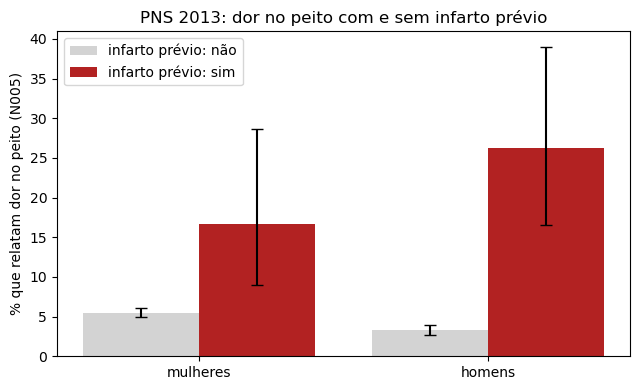

In [15]:
razao = (
    pns_sexo.pivot(index="sexo", columns="infarto prévio", values="%")
    .assign(**{"razão (com ÷ sem infarto)": lambda t: (t["sim"] / t["não"]).round(1)})
)
print(razao.to_string())

fig, eixo = plt.subplots(figsize=(6.5, 4))
for deslocamento, (infarto, cor) in zip((-0.2, 0.2), (("não", "lightgray"), ("sim", "firebrick"))):
    dados = pns_sexo[pns_sexo["infarto prévio"] == infarto].set_index("sexo").loc[["mulheres", "homens"]]
    limites = dados["IC 95%"].str.split("–", expand=True).astype(float)
    erros = [dados["%"] - limites[0], limites[1] - dados["%"]]
    eixo.bar(np.arange(2) + deslocamento, dados["%"], 0.4, yerr=erros, capsize=4, color=cor, label=f"infarto prévio: {infarto}")
eixo.set_xticks([0, 1], ["mulheres", "homens"])
eixo.set_ylabel("% que relatam dor no peito (N005)")
eixo.set_title("PNS 2013: dor no peito com e sem infarto prévio")
eixo.legend()
plt.tight_layout()
plt.show()

In [16]:
com_infarto = pns[pns["infarto"]]
pd.DataFrame([
    {"grupo (infarto prévio)": f"diabetes: {g}", "pessoas": len(t), "relatam dor no peito": int(t["dor"].sum()), "%": round(100 * t["dor"].mean(), 1)}
    for g, t in com_infarto.groupby("Diabetes_Diagnosticado")
])

,grupo (infarto prévio),pessoas,relatam dor no peito,%
0,diabetes: Nao,83,21,25.3
1,diabetes: Sim,27,3,11.1


**Leitura:**

- **Entre quem já teve infarto**, 16,7% das mulheres relatam dor no peito, contra 26,3% dos homens.
- **Entre quem não teve infarto**, a relação se inverte: 5,5% das mulheres e 3,3% dos homens.
- Na prática, "dor no peito" é um sinal de infarto **cerca de 3 vezes mais frequente** em quem teve infarto, entre mulheres, e **cerca de 8 vezes**, entre homens. O sintoma clássico **discrimina muito menos para mulheres**: é mais comum sem doença e menos comum com doença.
- O mesmo padrão aparece em **diabéticos**: 11% dos que tiveram infarto relatam dor, contra 25% dos não diabéticos. Isso é compatível com isquemia silenciosa.

**Ressalvas (sérias):**

- São poucos casos (54 mulheres e 57 homens com infarto). Os intervalos de confiança entre os infartados se sobrepõem, então a diferença é **sugestiva, não conclusiva**.
- O N005 pergunta sobre dor **ao caminhar**, não sobre dor aguda de infarto.
- O infarto é **autorreferido**, e o estudo é transversal.
- Raça e região não foram analisadas porque há poucos infartos por grupo (ex.: 10 em pessoas pretas).

**Implicação para o CardioIA:** um sistema centrado em "dor no peito" tende a **subtriar mulheres e diabéticos**. Por isso:

- o critério **A4 (equivalente atípico)** existe;
- o dataset tem frases atípicas e vozes femininas;
- o próximo passo é medir o **recall separado por sexo** com dados clínicos reais (anonimizados e autorizados).

## 10. Resumo dos vieses

| Viés | Evidência | Mitigação feita | Pendente |
|---|---|---|---|
| **Vocabulário de livro** (regras) | 6/15 casos de comportamento errados; recall 0,43 no teste | ML treinado com frases variadas; regras usadas como rede de segurança | Ampliar a base com expressões coloquiais validadas |
| **Negação** (ML) | Negar o sintoma quase não muda P(alto) (seção 4) | Extrator com NegEx; regras acertam todos os pares | Combinação ML + regras (seção 7) a confirmar em teste novo |
| **Pistas espúrias** (templates) | "Comecei a sentir… agora" inverte a classe (seção 5) | Detectado e documentado | Variar os moldes entre classes; mais frases manuais |
| **Gênero gramatical** | Lacunas reais em 2 expressões e 4 atributos da base | Contrato de paridade de gênero + teste contrafactual (0 inversões) | — |
| **Conjugação verbal** (regras) | Dispneia grave: 1/5 nas regras ("acordei" × "acordo") | Detectado e documentado | Lematização no extrator |
| **Apresentação atípica** (mulheres, diabéticos) | PNS 2013: dor no peito discrimina ~3× em mulheres contra ~8× em homens | Critério A4 + frases atípicas no dataset | Medir recall por sexo com dados reais; validação clínica |
| **Autoria única do dataset** | Treino e teste escritos pelo mesmo autor | Teste congelado antes da avaliação; linhagem explícita | Teste cego escrito pela equipe |

---

> ⚠️ **AVISO CLÍNICO:** Este sistema é um protótipo acadêmico e **NÃO** substitui avaliação médica.  
> Supervisionado por Dra. Fernanda Fassina (CRM-SP 169944).